### Simple Linear Regression

In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [80]:
df = pd.read_csv('../../all_datasets/placement.csv')
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


Text(0, 0.5, 'Package(in lpa)')

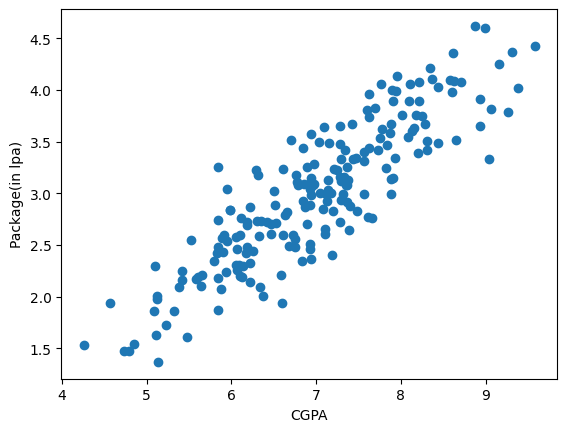

In [81]:
plt.scatter(df['cgpa'],df['package'])
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

In [82]:
X = df.iloc[:, 0:1]
y = df.iloc[:, -1]

In [83]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [84]:
X_train

,cgpa
134,7.20
66,5.11
26,8.31
113,6.94
168,8.65
...,...
67,6.51
192,8.25
117,7.12
47,5.84


In [85]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

In [86]:
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [87]:
X_test

,cgpa
18,6.94
170,6.22
107,6.33
98,7.69
177,7.09
182,5.88
5,7.89
146,6.07
12,8.94
152,7.37


In [88]:
y_test

18     2.98
170    2.87
107    2.59
98     3.83
177    3.64
182    2.08
5      2.99
146    2.46
12     3.65
152    3.08
61     1.61
125    3.16
180    2.72
154    2.85
80     3.44
7      2.48
33     2.73
130    2.49
37     2.43
74     3.44
183    2.72
145    2.18
45     3.58
159    4.08
60     2.19
123    2.30
179    3.03
185    3.18
122    2.01
44     1.86
16     2.35
55     3.39
150    2.73
111    2.25
22     2.30
189    4.06
129    3.12
4      3.57
83     3.49
106    2.19
Name: package, dtype: float64

In [89]:
lr.predict(X_test.iloc[0].values.reshape(1,1))

/home/grow-lt-361/Code/Python/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([2.97012606])

Text(0, 0.5, 'Package(in lpa)')

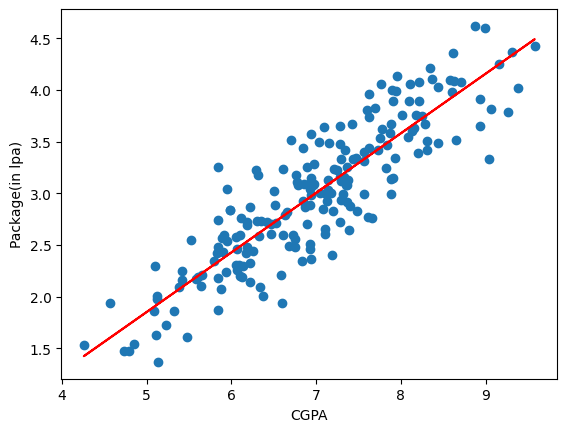

In [90]:
plt.scatter(df['cgpa'],df['package'])
plt.plot(X_train, lr.predict(X_train), color='red')
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

In [91]:
y_pred = lr.predict(X_test)

In [118]:
y_test

18     2.98
170    2.87
107    2.59
98     3.83
177    3.64
182    2.08
5      2.99
146    2.46
12     3.65
152    3.08
61     1.61
125    3.16
180    2.72
154    2.85
80     3.44
7      2.48
33     2.73
130    2.49
37     2.43
74     3.44
183    2.72
145    2.18
45     3.58
159    4.08
60     2.19
123    2.30
179    3.03
185    3.18
122    2.01
44     1.86
16     2.35
55     3.39
150    2.73
111    2.25
22     2.30
189    4.06
129    3.12
4      3.57
83     3.49
106    2.19
Name: package, dtype: float64

In [117]:
y_pred

array([2.97012606, 2.55516816, 2.61856451, 3.40237388, 3.05657563,
       2.35921582, 3.51763996, 2.4687186 , 4.1227869 , 3.21794814,
       2.12868365, 3.19489493, 2.53787825, 3.05081232, 3.36779405,
       2.86062328, 2.63009112, 2.82028015, 2.37074243, 2.91825632,
       3.1660784 , 2.3361626 , 3.50611335, 3.9902309 , 2.20360661,
       1.90967809, 3.08539215, 2.6070379 , 1.9212047 , 1.90391479,
       2.91249302, 3.69630239, 2.60127459, 2.09410383, 2.50906173,
       3.64443265, 3.17184171, 2.97012606, 3.83462169, 2.50329842])

In [120]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Assuming you already have y_test and y_pred
print("--- Regression Metrics ---")

# 1. R-squared (Closer to 1.0 is better)
r2 = r2_score(y_test, y_pred)
print(f"R-squared: {r2}")

# 2. Mean Absolute Error (Lower is better)
mae = mean_absolute_error(y_test, y_pred)
print(f"MAE: {mae}")

# 3. Root Mean Squared Error (Lower is better)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) 
print(f"RMSE: {rmse}")

--- Regression Metrics ---
R-squared: 0.7297167943957027
MAE: 0.25524334486204076
RMSE: 0.31970503685951224


In [124]:
m = lr.coef_
m

array([0.57633042])

In [125]:
b = lr.intercept_
b

np.float64(-1.0296070415163103)